## Orchestrator - Worker 

Orchestrator :
  - Breaks down the tasks into subtasks
  - Delegates subtasks to workers
  
Workers: Perform the tasks / Subtasks

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [3]:
from typing import List, Dict, Annotated, Optional
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from IPython.display import Image
from pydantic import BaseModel, Field

c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
class Section(BaseModel):
    name: str = Field(description='Name of the section of the report')
    description: str = Field(description='Breif overview of the main topics and concepts to be covered in this section')

class Sections(BaseModel):
    sections: List[Section] = Field(description='Sections of the report')

planner = model.with_structured_output(Sections)

In [5]:
response = planner.invoke(
    "Create a detailed outline for a technical report on the topic of 'The Impact of Artificial Intelligence on Modern Healthcare'. " +
    "The report should be divided into sections, each with a name and a brief description of the main topics to be covered."
)
for section in response.sections:
    print(f"Section: {section.name}\nDescription: {section.description}\n")

Section: Introduction
Description: Defines artificial intelligence (AI) in the context of healthcare, explains the purpose and scope of the report, outlines key questions addressed, and briefly introduces the major domains where AI is impacting modern healthcare (clinical, operational, administrative, and patient-facing).

Section: Background and Evolution of AI in Healthcare
Description: Provides historical context of AI development and its adoption in healthcare, including early expert systems, machine learning, and the rise of deep learning; reviews key technological milestones, regulatory and infrastructural changes, and the current state of AI maturity across healthcare systems globally.

Section: Core AI Technologies Used in Healthcare
Description: Describes the main AI methods and technologies applied in healthcare, including machine learning (supervised, unsupervised, and reinforcement learning), deep learning and neural networks, natural language processing, computer vision, a

Making the Orchestrator and Workers

In [21]:
from langgraph.graph import START, END, StateGraph
from langgraph.types import Send
from typing import TypedDict, Annotated
import operator
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from IPython.display import Image, Markdown

In [22]:
class Section(BaseModel):
    name: str = Field(description='Name of the section of the report')
    description: str = Field(description='Breif overview of the main topics and concepts to be covered in this section')

class State(TypedDict):
    topic: str
    sections: list[Section]
    complted_sections : Annotated[list, operator.add]
    final_report: str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [23]:
planner = model.with_structured_output(Sections)

In [31]:
def orchestrator(state: State):
    '''Orchestrator that generates a plan for the report'''
    report_sections = planner.invoke([
        SystemMessage("Generate a plan for the report."),
        HumanMessage(f"Here is the report topic: {state['topic']}")
    ])
    return {'sections': report_sections.sections}

def worker(state: WorkerState):
    '''Worker that writes a section of the report'''
    section_content = model.invoke([
        SystemMessage("Write a detailed section for the report based on the following section name and description."),
        HumanMessage(f"Here is the section name {state['section'].name} and description {state['section'].description}")
    ]).content
    return {'complted_sections': [section_content]}

def synthesizer(state: State) -> State:
    '''Synthesizer that combines all the completed sections to a final repot'''
    completed_sections = state['complted_sections']

    final_report = model.invoke([
        SystemMessage('combine the folowing completed sections into a comprehensice report'),
        HumanMessage('\n\n---\n\n'.join(completed_sections))
    ]).content

    return {'final_report': final_report}


def assign_worker(state: State):
    '''Assign workers to each section of the plan'''
    return [Send('worker', {'section': s}) for s in state['sections']]

Send API - Dynamacially creates the worker nodes and send them the specific inputs.
- Each worker node has its own satate, and 
- all workers outputs are written to a shared state key that is to accessible to teh orchestrator.

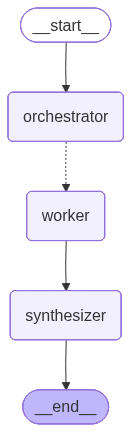

In [32]:
orch_builder = StateGraph(State)

orch_builder.add_node('orchestrator', orchestrator)
orch_builder.add_node('worker', worker)
orch_builder.add_node('synthesizer', synthesizer)

orch_builder.add_edge(START, 'orchestrator')
orch_builder.add_conditional_edges(
    'orchestrator',
    assign_worker,
    ['worker']
)
orch_builder.add_edge('worker', 'synthesizer')
orch_builder.add_edge('synthesizer', END)

orch_flow = orch_builder.compile()

orch_flow

In [33]:
initial_state = {"topic": "AI in Assest Mangement"}
final_state = orch_flow.invoke(initial_state)

Markdown(final_state['final_report'])

# Artificial Intelligence in Asset Management  
*A Comprehensive Report*

---

## 1. Introduction

Asset management is the systematic process of developing, operating, maintaining, upgrading, and disposing of assets in a cost‑effective and sustainable way. In finance, this includes physical infrastructure, financial instruments, and increasingly digital assets such as data, software, and intellectual property.

Effective asset management ensures that assets deliver maximum value over their lifecycle while meeting organizational goals, regulatory requirements, and stakeholder expectations. In financial markets, this translates into preserving and growing clients’ capital in line with risk and return objectives, under strong fiduciary and regulatory oversight.

The importance of asset management has grown as organizations confront aging infrastructure, tighter margins, stricter regulation, climate and sustainability commitments, and rising expectations for service quality and reliability. Poor asset management can lead to unplanned downtime, safety incidents, excessive costs, and loss of competitiveness. Robust practices, supported by frameworks such as ISO 55000, help optimize lifecycle costs, extend asset life, manage risk, improve safety, and support strategic decision‑making.

Artificial intelligence (AI) has emerged as a transformative technology within this context. AI—encompassing machine learning, deep learning, natural language processing (NLP), and optimization—enables systems to learn from data, identify patterns, and support or automate decisions. Applied to asset management and investment, AI can ingest large, heterogeneous datasets from markets, balance sheets, sensors, enterprise systems, maintenance logs, client interactions, and external sources to:

- Predict failures and deterioration (physical assets) or defaults and credit events (financial assets).
- Optimize asset performance, investment portfolios, and lifecycle costs.
- Enhance risk assessment and scenario analysis.
- Automate routine analysis, monitoring, and reporting.

The integration of AI is driving asset management from reactive, schedule‑based practices toward proactive, data‑centric, and increasingly autonomous approaches. This brings significant opportunities but also new challenges around data quality, model transparency, workforce skills, governance, ethics, and regulation.

### 1.1 Scope of the Report

This report focuses on the application of AI to asset management with emphasis on:

- Financial asset management (equities, fixed income, alternatives, multi-asset).
- Industrial and infrastructure contexts where physical and financial asset management converge (energy, transportation, manufacturing, utilities).
- Digital assets and data as strategic resources.

It examines AI across the full asset lifecycle—planning, acquisition, operation, maintenance, and decommissioning/renewal—covering both:

- **Technological aspects**: AI methods, data and IT architectures, integration with existing systems.
- **Organizational aspects**: governance, risk and compliance, processes, roles, skills, and culture.

The report highlights current, practical applications while also exploring emerging trends and future directions.

### 1.2 Objectives

The report has four main objectives:

1. **Clarify concepts and context**  
   Explain core principles of asset management and how AI augments traditional practices.

2. **Describe current AI applications**  
   Survey and categorize AI use across investment and asset lifecycles, from research to operations.

3. **Assess benefits, challenges, and risks**  
   Analyze the benefits of AI and examine technical, organizational, regulatory, and ethical risks.

4. **Offer guidance for implementation**  
   Provide practical recommendations on strategy, governance, change management, and capability development.

### 1.3 Structure of the Report

The report is organized as follows:

- Section 2 – Foundations of Asset Management  
- Section 3 – Foundations of AI Relevant to Asset Management  
- Section 4 – AI Applications Across the Investment Lifecycle  
- Section 5 – Use Cases in Investment Strategies  
- Section 6 – Operational and Back‑Office Applications  
- Section 7 – Benefits and Value Proposition  
- Section 8 – Risks, Limitations, and Challenges  
- Section 9 – Regulatory, Ethical, and Governance Considerations  
- Section 10 – Implementation Considerations for Asset Managers  
- Section 11 – Case Studies and Industry Examples  
- Section 12 – Future Trends and Outlook  
- Section 13 – Conclusion  

Together, these sections provide a comprehensive view of how AI is transforming asset management, what value it can unlock, and what is required to adopt it responsibly.

---

## 2. Foundations of Asset Management

### 2.1 Overview

In finance, asset management refers to the professional management of investments—equities, fixed income, real estate, alternatives, and cash—on behalf of individuals and institutions. The core objective is to preserve and grow clients’ capital in line with specified risk and return objectives while complying with legal, regulatory, and fiduciary obligations.

The traditional asset management value chain spans portfolio construction, risk management, investment research, and compliance. It operates within an ecosystem of multiple stakeholders—asset managers, institutional investors, retail investors, regulators, and service providers—and is currently reshaped by data proliferation, fee pressure, and regulatory complexity.

### 2.2 Traditional Asset Management Processes

#### 2.2.1 Portfolio Construction

Portfolio construction involves:

- Defining client objectives, constraints, time horizons, and risk tolerance.
- Strategic asset allocation (long-term mix of asset classes) based on capital market assumptions and frameworks such as mean-variance optimization or liability-driven investing.
- Tactical and dynamic allocation in response to market conditions, valuations, and risk indicators.
- Security selection using fundamental, quantitative, or hybrid approaches.
- Ongoing monitoring and rebalancing to manage risk, drift, and transaction cost trade-offs.

#### 2.2.2 Risk Management

Risk management ensures portfolios remain aligned with agreed risk profiles:

- Identification and measurement of market, credit, liquidity, operational, and counterparty risks using VaR, stress testing, factor models, and tracking error.
- Risk budgeting and limits on exposures, leverage, derivatives, and drawdowns.
- Governance through risk committees and independent risk teams, ensuring alignment with firm-wide risk appetite and regulation.

#### 2.2.3 Investment Research

Research underpins portfolio decisions:

- Fundamental analysis of companies, sectors, and themes.
- Quantitative research using factor models, statistical and ML methods.
- Macroeconomic and top‑down analysis of growth, inflation, policy, and geopolitics.
- ESG and sustainability research, integrating environmental, social, and governance factors into investment decisions.

#### 2.2.4 Compliance and Regulatory Oversight

Compliance ensures adherence to laws, regulations, client mandates, and internal policies:

- Pre‑trade and post‑trade controls to prevent and detect guideline breaches.
- Regulatory reporting and disclosure (holdings, risk, stress test results).
- Management of conflicts of interest and fiduciary duties.
- Policies, training, surveillance, and audits to maintain alignment with evolving standards.

### 2.3 Key Stakeholders

#### 2.3.1 Asset Managers

Firms and professionals designing and managing strategies:

- Portfolio managers, CIOs, analysts, traders.
- Risk, compliance, and operations teams.

#### 2.3.2 Institutional Investors

Large organizations investing on behalf of beneficiaries:

- Pension funds, insurance companies, sovereign wealth funds, central banks.
- Endowments, foundations, charities.

#### 2.3.3 Retail Investors

Individuals accessing investments via:

- Mutual funds and ETFs.
- Wealth management and advisory platforms.
- Digital platforms and robo‑advisors.

#### 2.3.4 Regulators and Supervisory Bodies

Entities ensuring market integrity and investor protection:

- Securities and prudential regulators.
- Self-regulatory organizations and industry bodies.

### 2.4 Current Structural Challenges

#### 2.4.1 Data Overload and Complexity

- Explosion of traditional and alternative data.
- Low signal‑to‑noise ratio and risk of overfitting.
- Infrastructure and talent requirements.
- Data governance and quality challenges.

#### 2.4.2 Fee Pressure and Margin Compression

- Growth of low‑cost passive investing.
- Client demand for demonstrable value for active fees.
- Regulatory-driven transparency.
- Impact on business models and consolidation.

#### 2.4.3 Regulatory Complexity

- Expanding and evolving regulatory scope (including ESG).
- Jurisdictional fragmentation.
- Frequent changes and interpretive uncertainty.
- Rising cost and operational burden of compliance.

---

## 3. Foundations of AI Relevant to Asset Management

AI in asset management leverages machine learning, NLP, and advanced analytics, supported by solid data and infrastructure.

### 3.1 Machine Learning (ML)

#### 3.1.1 Supervised Learning

Models learn mappings from features to labels:

- Applications: return prediction, alpha modeling, credit risk, client analytics.
- Techniques: regressions, tree-based models, regularized models, neural networks.
- Considerations: overfitting, proper backtesting, interpretability.

#### 3.1.2 Unsupervised Learning

Models discover structure without labels:

- Applications: clustering securities/clients, factor discovery, anomaly detection.
- Techniques: clustering (k‑means, hierarchical), PCA, autoencoders, density-based methods.

#### 3.1.3 Reinforcement Learning (RL)

Agents learn sequential decision policies:

- Applications: dynamic asset allocation, execution, hedging (mostly experimental).
- Challenges: realistic simulations, overfitting, regulatory limits on autonomy.

### 3.2 Natural Language Processing (NLP)

NLP extracts insight from text:

- Techniques: text representation, document classification, sentiment analysis, information extraction, topic modeling, summarization, LLMs.
- Applications: event and sentiment-driven signals, ESG analysis, research productivity, compliance surveillance.

### 3.3 Alternative Data Analytics

Alternative data includes:

- Transactional and behavioral data.
- Web and online data.
- Geospatial and sensor data.
- Supply chain data.
- ESG and climate data.

AI supports:

- Cleaning and entity resolution.
- Feature engineering and signal extraction.
- High-dimensional modeling and nowcasting.

### 3.4 Supporting Infrastructure

#### 3.4.1 Data Architecture and Pipelines

- Data ingestion and integration.
- Quality and governance.
- ETL/ELT and orchestration.

#### 3.4.2 Cloud Computing and Storage

- Elastic compute (CPU/GPU), containers, serverless.
- Data lakes, warehouses, lakehouses.
- Managed AI services with security and compliance.

#### 3.4.3 MLOps and Model Lifecycle

- Version control and reproducibility.
- Deployment and integration.
- Monitoring, retraining, and model risk management.
- Governance and documentation.

---

## 4. AI Applications Across the Investment Lifecycle

AI increasingly supports all stages of the investment process.

### 4.1 Idea Generation and Research

- **Structured data**: ML forecasting, factor discovery, integration of alternative structured data.
- **Unstructured data**: NLP on earnings calls, filings, news; event detection; computer vision (satellite, imagery); generative AI for research summaries and Q&A.

### 4.2 Portfolio Construction and Optimization

- Enhanced return and risk estimation using ML.
- Scenario-aware and multi-objective optimization (return, risk, ESG, liquidity).
- Dynamic allocation, including RL-based approaches.
- Individualized and thematic portfolios, especially in wealth management.

### 4.3 Execution and Trading

- Algorithmic execution enhanced by AI:
  - Adaptive execution strategies.
  - Short-term price and liquidity forecasts.
- Smart order routing (SOR) using ML/RL.
- Automation combined with trader supervision and anomaly detection.

### 4.4 Risk Management and Stress Testing

- Real-time risk monitoring and anomaly detection.
- Dynamic risk factor models capturing nonlinearities.
- Scenario generation via generative models and ML-based simulators.
- Integration of non-financial risks (regulatory, geopolitical, climate) via NLP.
- Model risk management and explainability tools.

### 4.5 Monitoring and Reporting

- Continuous portfolio monitoring via dashboards and alerts.
- Enhanced performance and attribution analytics.
- Automated report generation with generative AI.
- On-demand, conversational reporting for clients.
- ESG, compliance, and operational monitoring via AI.

---

## 5. Use Cases in Investment Strategies

### 5.1 Quantitative and Factor Investing

- Signal discovery and feature engineering from diverse datasets.
- Dynamic factor weighting and regime detection.
- Advanced portfolio construction and cost-aware optimization.

### 5.2 Smart Beta Strategies

- AI-based factor definition and refinement.
- Dynamic rebalancing and turnover control.
- Risk analytics and customization for client constraints.

### 5.3 Robo-Advisory and Digital Wealth

- Personalized portfolio construction based on richer profiling.
- Intelligent rebalancing and tax optimization.
- Client engagement, behavioral coaching, and conversational AI.

### 5.4 ESG Scoring and Integration

- Data aggregation and normalization from multiple ESG sources.
- Real-time controversy detection and monitoring.
- Multi-objective optimization including ESG metrics.
- Climate scenario analysis and engagement targeting.

### 5.5 Credit and Fixed-Income

- NLP for credit signals, combined with ML-based stress models.
- Loan-level modeling for structured products.
- Yield curve and spread modeling using ML.
- Liquidity-aware execution in OTC markets.

### 5.6 Alternative Investments

- Hedge funds: event-driven, statistical arbitrage, systematic macro.
- Private equity and VC: deal sourcing, due diligence, portfolio monitoring.
- Real estate and infrastructure: valuation, market selection, physical risk assessment.
- Alternative data-driven strategies across sectors.

### 5.7 Performance and Efficiency Enhancements

Common contributions across strategies:

- Improved signal quality and forecast accuracy.
- Faster reaction and intraday adaptability.
- Scalability of research and portfolio management.
- Cost reduction and enhanced risk control.

---

## 6. Operational and Back‑Office Applications

AI is transforming middle- and back-office functions.

### 6.1 Client Onboarding and KYC

- Intelligent document processing (OCR + NLP).
- Automated sanctions and PEP screening.
- ML-based risk scoring and dynamic updates.
- Improved client experience through guided onboarding.

### 6.2 Regulatory Reporting

- Data integration and quality control with anomaly detection.
- NLP-based regulatory text analysis and impact assessment.
- Automated and near real-time reporting with pre-submission checks.

### 6.3 Compliance Monitoring

- Transaction and trade surveillance using ML.
- E‑communications monitoring using NLP for conduct risk.
- Automated controls and continuous control testing.

### 6.4 Operational Risk Detection

- Anomaly detection in process and systems data.
- Predictive risk analytics and incident prediction.
- Operational resilience through AI-based monitoring and scenario analysis.

### 6.5 Workflow Automation

- Intelligent process automation (RPA + AI).
- Dynamic case routing and prioritization.
- Knowledge retrieval and generative drafting of responses and documentation.

### 6.6 Cost Reduction and Efficiency

- Automation of low-value tasks and increased throughput.
- Reduced errors, rework, and audit burden.
- Faster time‑to‑market and improved capital/risk management.

### 6.7 Implementation Risks

- Data privacy and security.
- Model risk, explainability, and bias.
- Change management and workforce adaptation.

---

## 7. Benefits and Value Proposition

AI’s value in asset management spans multiple dimensions.

### 7.1 Improved Alpha Generation

- Better pattern recognition in complex, noisy data.
- Faster signal discovery and strategy iteration.
- Dynamic models adapting to changing markets.
- Broader coverage of assets and markets.

### 7.2 Better Risk-Adjusted Returns

- Enhanced risk modeling and scenario analysis.
- Early warning systems for emerging risks.
- Dynamic hedging and allocation adjustments.

### 7.3 Enhanced Personalization

- Individualized portfolios incorporating objectives, constraints, and preferences.
- Behavior-aware advice and nudging.
- Smart rebalancing with tax and fee optimization.
- Personalized communication at scale.

### 7.4 Operational Efficiency

- Automation of routine tasks and processes.
- Intelligent data management and quality.
- Streamlined compliance and reporting.
- Productivity gains in research and analysis.

### 7.5 Scalability

- Mass customization of portfolios and services.
- Reuse of core AI components across products.
- Efficient global coverage with finite resources.

### 7.6 Improved Client Experience

- Real-time, interactive analytics and reporting.
- Conversational interfaces for queries and explanations.
- Proactive engagement and tailored education.
- Greater transparency around investment processes.

### 7.7 Strategic Differentiation

- Differentiated capabilities in data and models.
- Proprietary data and insights as enduring assets.
- Enhanced resilience and adaptability.

---

## 8. Risks, Limitations, and Challenges

AI introduces significant risks that must be managed holistically.

### 8.1 Model Risk

- Mis-specification, bias, and incorrect problem framing.
- Concept and data drift.
- Brittleness to unusual inputs.
- Need for rigorous validation, stress testing, and monitoring.

### 8.2 Data Quality

- Incomplete, noisy, or inconsistent data.
- Sampling and representation bias.
- Poor data lineage and provenance.

### 8.3 Overfitting and Generalization

- Over-parameterized models.
- Leakage and flawed validation.
- Limited exposure to rare or extreme events.

### 8.4 Transparency and Explainability

- Opaque decision logic in complex models.
- Regulatory and ethical demands for explainability.
- Limitations of post-hoc explanation tools.

### 8.5 Operational and Cyber Risks

- Integration failures and process breakdowns.
- Reliability and availability challenges.
- Security vulnerabilities (adversarial attacks, data poisoning, model theft).
- Privacy breaches.

### 8.6 Talent and Cultural Challenges

- Skills gaps in AI, data, and MLOps.
- Misaligned incentives and change resistance.
- Over-trust or under-trust in automation.
- Ethical alignment and accountability.

### 8.7 Systemic Risks

- Amplification of biases at scale.
- Herding and correlated behavior among AI-driven strategies.
- Concentration of technological power and dependency.
- Labor market disruption and broader societal impacts.

---

## 9. Regulatory, Ethical, and Governance Considerations

AI in finance operates under increasingly explicit regulatory expectations and ethical scrutiny.

### 9.1 Emerging Regulatory Frameworks

- EU AI Act, NIS2, DORA.
- US supervisory guidance on model risk, fair lending, and algorithmic trading.
- UK and other jurisdictions’ principles-based approaches.
- MAS FEAT principles and other regional frameworks.

Common themes:

- Risk-based, proportionate regulation.
- Governance and accountability.
- Model risk management.
- Fairness, transparency, and privacy.
- Operational resilience and cybersecurity.

### 9.2 Model Governance

- Board and senior management oversight.
- Three lines of defense adapted to AI.
- Model inventory, classification, and lifecycle management.
- Independent validation and continuous monitoring.
- Documentation and explainability requirements.

### 9.3 Fairness and Bias

- Data and algorithmic sources of bias.
- Fairness objectives and metrics (e.g., equal opportunity, equalized odds).
- Design-time and run-time interventions to mitigate bias.
- Regular fairness audits and stakeholder engagement.

### 9.4 Privacy and Data Protection

- Compliance with GDPR and similar regimes.
- Data lifecycle management, minimization, and anonymization.
- Strong access control and security.
- Transparent automated decision-making and appeal processes.

### 9.5 Oversight and Ethical Frameworks

- Institution-specific AI ethics principles.
- Cross-functional AI governance bodies.
- Clear ownership and incident response protocols.
- Vendor and third-party governance.

---

## 10. Implementation Considerations for Asset Managers

Successful AI adoption requires coordinated action across strategy, technology, and organization.

### 10.1 Align AI with Business Strategy

- Identify and prioritize high-value use cases.
- Define success metrics and risk appetite.
- Distinguish between decision support and automation.

### 10.2 Build vs. Buy Decisions

- Build where AI is core to differentiation or heavily customized.
- Buy for commodity or generic capabilities and where speed is critical.
- Use hybrid arrangements combining external platforms with internal models.

### 10.3 Data Strategy

- Comprehensive data inventory and classification.
- Standardized data models and quality controls.
- Centralized, accessible data platforms.
- Data governance and ethical use policies.

### 10.4 Technology Architecture

- Cloud or hybrid data and compute platforms.
- MLOps tooling for model lifecycle.
- API-based integration with OMS/PMS, risk, CRM.
- LLM/GenAI considerations: model choice, RAG, content filtering, oversight.

### 10.5 Vendor Selection and Ecosystem

- Evaluate domain expertise, transparency, integration, and security.
- Clarify IP ownership, SLAs, and exit strategies.
- Maintain vendor inventory and risk-based oversight.

### 10.6 Organizational Change

- Engage stakeholders early and often.
- Position AI as augmentative, not purely substitutive.
- Embed governance and risk management from the outset.
- Pilot, iterate, and scale based on evidence.

### 10.7 Talent and Skills

- Hire and develop data scientists, ML engineers, data engineers, AI product managers, and model risk specialists.
- Upskill existing staff in data literacy and AI usage.
- Foster continuous learning and cross-functional collaboration.

---

## 11. Case Studies and Industry Examples

Real-world implementations illustrate both success and pitfalls.

### 11.1 Large Asset Manager: AI-Enhanced Research

- NLP and LLMs for parsing and summarizing earnings calls, filings, and research.
- Internal AI “copilot” for analysts.
- Outcomes: 20–30% productivity gains, broader coverage, faster event response.
- Lessons: human-in-the-loop, data governance, change management, nuanced evaluation.

### 11.2 Quant Hedge Fund: AI-Driven Systematic Strategies

- ML for signal generation and risk modeling.
- RL for execution optimization.
- Outcomes: improved risk-adjusted returns, lower transaction costs, better drawdown management.
- Lessons: need for interpretability, retraining, integration with existing models, and infrastructure.

### 11.3 Retail Fintech: Personalized Advice

- ML for client profiling and segmentation.
- AI-driven portfolio construction and tax optimization.
- Behavioral nudging via NLP-powered communication.
- Outcomes: higher engagement, fewer panic sells, improved retention.
- Lessons: transparency, regulatory alignment, avoiding over-personalization.

### 11.4 Custodian and Asset Servicer: AI in Operations

- AI-driven document processing and anomaly detection.
- Enhanced compliance surveillance.
- Outcomes: reduced manual workload, improved control effectiveness.
- Lessons: human oversight for critical flows, robust governance, tackling legacy data.

### 11.5 Unsuccessful Case: Black-Box Stock-Picking Tool

- Vendor AI integrated with minimal understanding.
- Strong early performance followed by regime-driven failure.
- Outcomes: risk deviations, client distrust, product restructuring.
- Lessons: dangers of opaque third-party models, lack of internal expertise, inadequate testing and governance.

### 11.6 Common Themes

Success factors:

- Clear problem definition.
- Human-centric design.
- Strong data and governance foundations.
- Iterative deployment and experimentation.
- Emphasis on explainability and trust.

Pitfalls:

- Technology-led initiatives without clear use case.
- Overreliance on black-box models.
- Weak change management.
- Neglect of model and operational risk.

---

## 12. Future Trends and Outlook

The next decade will see deeper integration of AI and related technologies.

### 12.1 Generative AI as an Intelligence Layer

- Continuous synthesis of research insights.
- Automated drafting of documents and disclosures.
- Conversational interfaces for complex queries and scenario analysis.
- Heightened governance and explainability needs.

### 12.2 Real-Time Analytics and Always-On Risk

- Streaming data and intraday analytics.
- Event-driven portfolio management and dynamic hedging.
- Continuous risk and liquidity monitoring.
- More proactive operational control and exception handling.

### 12.3 AI-Driven Personalization at Scale

- Mass-customized portfolios (e.g., direct indexing).
- Behavioral analytics embedded in advice.
- Omnichannel, personalized client experiences.
- Regulatory focus on fairness and transparency in personalization.

### 12.4 Blockchain, Tokenization, and Programmable Assets

- Tokenization of traditional assets, enabling fractional ownership and faster settlement.
- On-chain funds and programmable compliance.
- More active secondary markets for private assets.
- Need for interoperability standards and regulatory clarity.

### 12.5 Convergence and Strategic Implications

- Integrated data and technology stacks become essential.
- Talent and organizational models evolve toward cross-functional teams.
- New business models and partnerships with fintechs and tech providers.
- Regulatory intensification around AI and digital assets.

### 12.6 Outlook

The industry is moving toward:

- More intelligent, responsive portfolios.
- More transparent and programmable financial products.
- More client-centric and personalized services.

Firms that invest in AI, data infrastructure, governance, and culture will shape the next era of asset management; laggards risk commoditization or disintermediation.

---

## 13. Conclusion

AI is reshaping asset management across the investment, operational, and client lifecycle.

### 13.1 Key Findings

- AI is deeply embedded in idea generation, portfolio construction, risk management, execution, operations, and client communication.
- The most effective applications augment human decision-making rather than replace it.
- Performance and efficiency gains are significant but contingent on data quality, governance, and organizational readiness.
- Data has become a strategic asset underpinning AI capabilities.
- Governance, risk management, and regulatory expectations are evolving quickly.

### 13.2 Strategic Importance

AI is now central to:

- Differentiating investment capabilities and alpha generation.
- Protecting margins via efficiency and scalability.
- Strengthening resilience and regulatory readiness.
- Enabling new product and service innovation, especially personalization.

### 13.3 Persistent Challenges

Remaining challenges include:

- Balancing model complexity with explainability.
- Ensuring data quality, fairness, and ethical use.
- Addressing talent and cultural barriers.
- Managing model and systemic risks.
- Navigating regulatory uncertainty and fragmentation.

### 13.4 Recommendations

**For Asset Managers**

- Develop a coherent AI strategy linked to business goals.
- Invest in data and infrastructure as foundational enablers.
- Strengthen model risk management and governance.
- Build multidisciplinary teams and upskill existing staff.
- Keep humans in the loop for significant decisions.
- Communicate transparently with clients about AI use.

**For Regulators and Policymakers**

- Provide clear, risk-based guidance focusing on outcomes.
- Coordinate across jurisdictions to reduce fragmentation.
- Support innovation sandboxes and safe experimentation.

**For Investors and Clients**

- Incorporate AI capability assessment into manager due diligence.
- Demand transparency and accountability regarding AI-driven processes.

AI is not a guarantee of superior outcomes nor a substitute for sound judgment and governance. Its strategic value lies in amplifying human capabilities, extracting more insight from data, and enabling new operating models. The critical question is how to adopt AI responsibly and effectively, delivering durable value to end investors while maintaining trust, fairness, and resilience.

Asset managers that can answer this question decisively—and execute on it—will be best positioned to lead in the evolving landscape of AI-enabled finance.